# IBM: July 14, 2026 Crash vs. Historical 10%+ Drops

This notebook pulls IBM's full daily price history from Yahoo Finance (via `yfinance`, free, no API key) and compares July 14, 2026 to the eight previous days IBM dropped 10%+ in a single session. It also compares against historical S&P 500 data, also pulled via `yfinance`).

In [1]:
!pip install -q yfinance

In [21]:
import yfinance as yf
import pandas as pd

ibm = yf.download("IBM", start="1968-01-01", end="2026-07-17", auto_adjust=False, progress=False)
ibm.columns = ibm.columns.get_level_values(0)  # drop the ticker level yfinance adds
ibm["Return"] = ibm["Adj Close"].pct_change()
ibm.tail()

Price,Adj Close,Close,High,Low,Open,Volume,Return
Date,,,,,,,
2026-07-10,287.559998,287.559998,298.769989,287.500000,297.260010,3640100,-0.026211
2026-07-13,290.230011,290.230011,297.500000,289.100006,290.500000,5024200,0.009285
2026-07-14,217.070007,217.070007,229.919998,213.220001,226.369995,67440900,-0.252076
2026-07-15,211.199997,211.199997,223.809998,211.029999,220.970001,29590400,-0.027042
2026-07-16,219.050003,219.050003,219.949997,204.440002,208.820007,22533300,0.037169


In [22]:
# Saving
ibm.to_csv(r'ibm_analysis.csv')

## Isolate the previous 10%+ drops, plus July 14, 2026

In [23]:
target_date = pd.Timestamp("2026-07-14")
target_return = ibm.loc[target_date, "Return"]

crashes = ibm[ibm["Return"] <= -0.10].copy()

comparison = crashes[["Adj Close", "Return"]].copy()
comparison.loc[target_date] = ibm.loc[target_date, ["Adj Close", "Return"]]
comparison["Return"] = (comparison["Return"] * 100).round(1)
comparison.columns = ["Adj Close ($)", "1-Day Return (%)"]
comparison

,Adj Close ($),1-Day Return (%)
Date,,
1987-10-19,9.070089,-23.5
1992-12-15,6.258266,-10.7
1999-10-21,44.398308,-15.0
2000-10-18,46.783020,-15.5
2002-04-08,43.170055,-10.1
2020-03-12,75.730331,-12.9
2026-02-23,221.718155,-13.1
2026-07-14,217.070007,-25.2


## How July 14, 2026 ranks against those eight drops

In [45]:
rank = (crashes["Return"] < target_return).sum() + 1 # ranks 1 if there are zero crashes beyond target
print(f"July 14, 2026 return: {target_return:.1%}")
print(f"Rank among all IBM 10%+ single-day drops: #{rank} of {len(crashes)}")
print(f"Median of the previous drops: {crashes['Return'].median():.1%}")
print(f"Worst of the previous drops: {crashes['Return'].min():.1%} on {crashes['Return'].idxmin().date()}")

July 14, 2026 return: -25.2%
Rank among all IBM 10%+ single-day drops: #1 of 8
Median of the previous drops: -14.1%
Worst of the previous drops: -25.2% on 2026-07-14


## Chart: the drops side by side

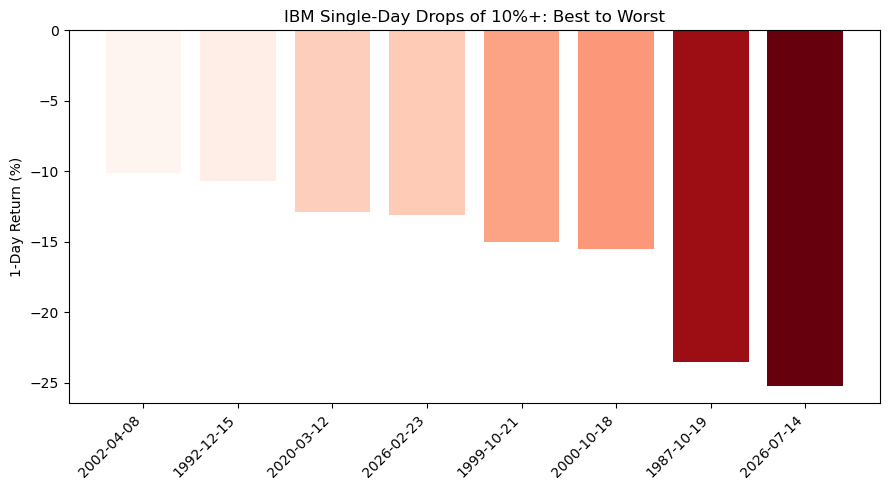

In [25]:
import matplotlib.pyplot as plt

sorted_comparison = comparison.sort_values("1-Day Return (%)", ascending=False)
labels = sorted_comparison.index.strftime("%Y-%m-%d")
returns = sorted_comparison["1-Day Return (%)"]

norm = plt.Normalize(returns.min(), returns.max())
colors = plt.cm.Reds_r(norm(returns))  # more negative return -> darker red

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(labels, returns, color=colors)
ax.set_ylabel("1-Day Return (%)")
ax.set_title("IBM Single-Day Drops of 10%+: Best to Worst")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## IBM and Expected Returns

In [33]:
import numpy as np

sp500 = yf.download("^GSPC", start="1968-01-01", end="2026-07-17", auto_adjust=False, progress=False)
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)
sp500["Return"] = sp500["Close"].pct_change()

paired = pd.concat([ibm["Return"].rename("IBM"), sp500["Return"].rename("Market")], axis=1).dropna()

# estimate beta from the 250 trading days before the event, so the crash itself doesn't distort it
event_idx = paired.index.get_loc(target_date)
window = paired.iloc[event_idx - 250 : event_idx]
beta, alpha = np.polyfit(window["Market"], window["IBM"], 1)

market_return = paired.loc[target_date, "Market"]
expected_return = alpha + beta * market_return
actual_return = paired.loc[target_date, "IBM"]
abnormal_return = actual_return - expected_return

print(f"Estimated beta (trailing 250 days): {beta:.2f}")
print(f"S&P 500 return on July 14, 2026: {market_return:.2%}")
print(f"Expected IBM return given its beta: {expected_return:.2%}")
print(f"Actual IBM return: {actual_return:.2%}")
print(f"Abnormal (IBM-specific) return: {abnormal_return:.2%}")

Estimated beta (trailing 250 days): 0.94
S&P 500 return on July 14, 2026: 0.38%
Expected IBM return given its beta: 0.33%
Actual IBM return: -25.21%
Abnormal (IBM-specific) return: -25.54%


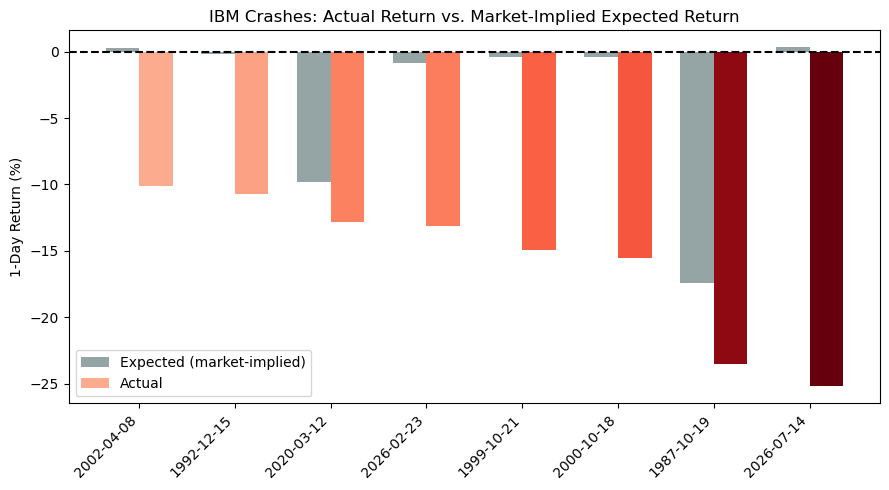

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors

event_study = event_study.sort_values("actual", ascending=False)  # least severe left, most severe right

severity = event_study["actual"].abs()
norm = colors.Normalize(vmin=severity.min(), vmax=severity.max())
red_shades = cm.Reds(0.3 + 0.7 * norm(severity))  # keep the mildest bar from going near-white

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(event_study))
width = 0.35

ax.bar(x - width/2, event_study["expected"] * 100, width, label="Expected (market-implied)", color="#95a5a6")
ax.bar(x + width/2, event_study["actual"] * 100, width, label="Actual", color=red_shades)

ax.set_xticks(x)
ax.set_xticklabels(event_study.index.strftime("%Y-%m-%d"), rotation=45, ha="right")
ax.set_ylabel("1-Day Return (%)")
ax.set_title("IBM Crashes: Actual Return vs. Market-Implied Expected Return")
ax.legend()
ax.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()